In [6]:
# -----------------------------
# Image Stitching Using Correlation & Weighted Blend
# -----------------------------

# source .venv/bin/activate

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter1d
from pathlib import Path 



BASE_DIR = Path.cwd()
PAR_DIR = BASE_DIR.parent
print(PAR_DIR)


/Users/ottobruce-gardyne/Documents/Year4/GIP/signal-processing-G2066


Path 1 exists: True
Path 2 exists: True


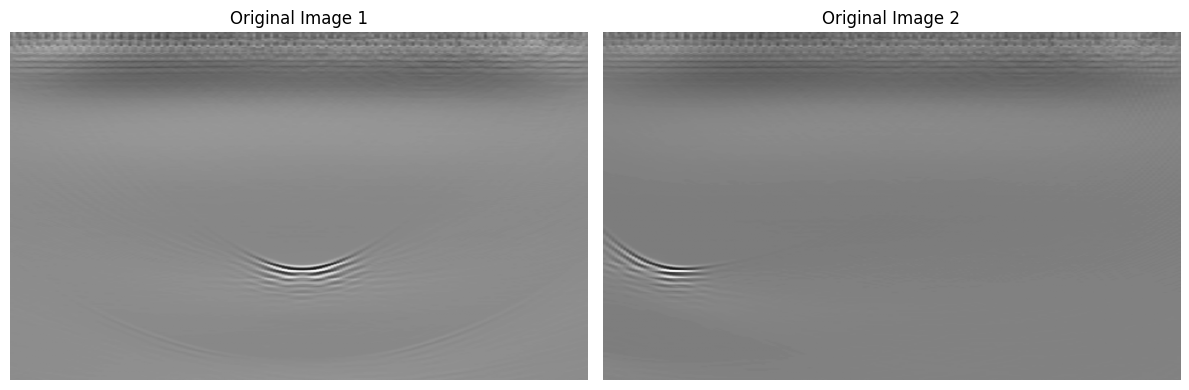

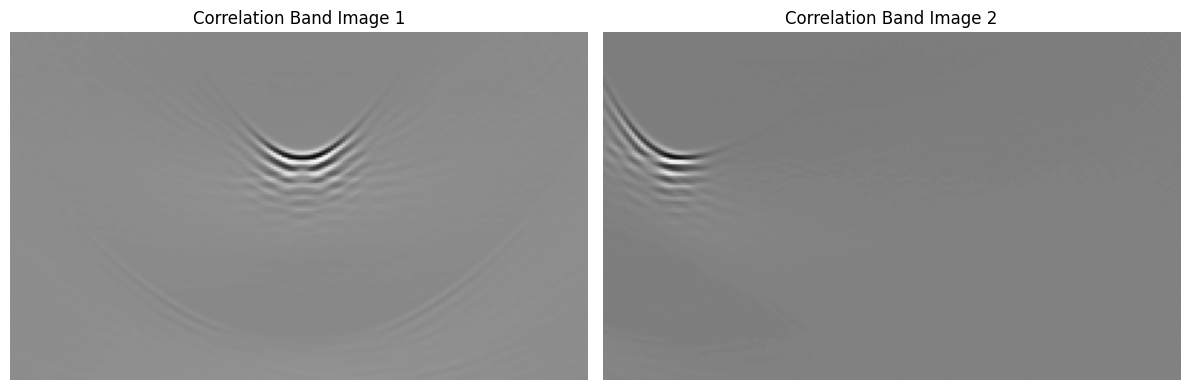

Best dx for stitching: 95


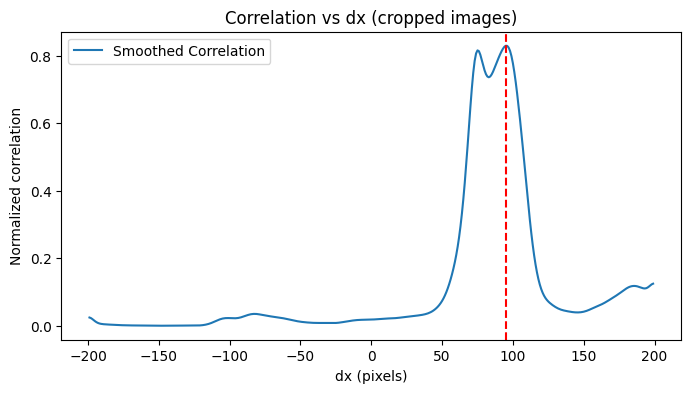

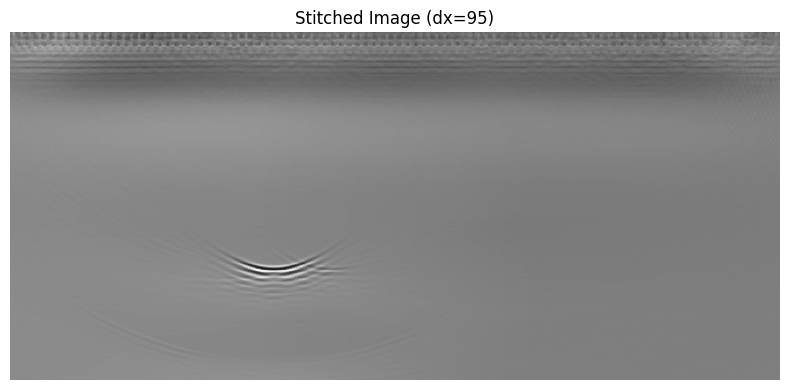

In [84]:
# -----------------------------
# Utility Functions
# -----------------------------

def show(img, title="", cmap="gray"):
    plt.figure(figsize=(8, 4))
    plt.imshow(img, cmap=cmap, aspect="auto")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_pair(a, b, title1="Image 1", title2="Image 2", cmap="gray"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(a, cmap=cmap, aspect="auto"); ax[0].set_title(title1); ax[0].axis("off")
    ax[1].imshow(b, cmap=cmap, aspect="auto"); ax[1].set_title(title2); ax[1].axis("off")
    fig.tight_layout()
    plt.show()

def preprocess_for_corr(img: np.ndarray) -> np.ndarray:
    """Normalize and emphasize horizontal edges for correlation"""
    x = img.astype(np.float32)
    x -= x.mean()
    x /= (x.std() + 1e-9)
    x = np.abs(np.gradient(x, axis=1))  # horizontal edges
    return x

def crop_depth_band(img: np.ndarray, y0: int, y1: int) -> np.ndarray:
    """Keep only rows y0:y1 for correlation"""
    return img[y0:y1, :]

# -----------------------------
# Correlation Function
# -----------------------------

def corr_curve_shift_x(img1: np.ndarray, img2: np.ndarray, dx_min: int, dx_max: int):
    """Compute normalized, smoothed correlation curve over dx range"""
    a = preprocess_for_corr(img1)
    b = preprocess_for_corr(img2)

    h, w1 = a.shape
    _, w2 = b.shape

    dxs = np.arange(dx_min, dx_max + 1)
    scores = np.full(dxs.shape, -np.inf, dtype=np.float32)

    for t, dx in enumerate(dxs):
        ov_start = max(0, dx)
        ov_end = min(w1, dx + w2)
        if ov_end <= ov_start:
            continue
        a_ov = a[:, ov_start:ov_end]
        b_ov = b[:, (ov_start - dx):(ov_end - dx)]
        scores[t] = np.sum(a_ov * b_ov) / a_ov.size

    # Normalize 0..1
    finite = np.isfinite(scores)
    s = scores[finite]
    if s.size == 0:
        corr01 = scores
    else:
        mn, mx = float(s.min()), float(s.max())
        corr01 = (scores - mn) / (mx - mn + 1e-12)

    # Smooth correlation curve
    corr01_smooth = gaussian_filter1d(corr01, sigma=3)
    return dxs, corr01_smooth

# -----------------------------
# Stitching & Blending
# -----------------------------

def stitch_canvas(img1: np.ndarray, img2: np.ndarray, dx: int):
    """Place two images on a single canvas according to dx"""
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    if h1 != h2:
        raise ValueError("Images must have the same height.")

    # Full canvas size
    x_min = min(0, dx)
    x_max = max(w1, dx + w2)
    W = x_max - x_min
    H = h1

    x1 = -x_min
    x2 = dx - x_min

    c1 = np.zeros((H, W), dtype=np.float32)
    c2 = np.zeros((H, W), dtype=np.float32)
    c1[:, x1:x1+w1] = img1.astype(np.float32)
    c2[:, x2:x2+w2] = img2.astype(np.float32)

    return c1, c2, x1, x2, W, H

def combine_weighted_blend(img1: np.ndarray, img2: np.ndarray, dx: int):
    """Blend two images using one seamless linear ramp in the overlap"""
    c1, c2, x1, x2, W, H = stitch_canvas(img1, img2, dx)

    ov_start = max(x1, x2)
    ov_end   = min(x1 + img1.shape[1], x2 + img2.shape[1])
    overlap  = max(0, ov_end - ov_start)

    out = np.zeros((H, W), dtype=np.float32)
    out[:, :ov_start] = c1[:, :ov_start]

    if overlap > 0:
        ramp = np.linspace(0, 1, overlap)[None, :]
        out[:, ov_start:ov_end] = (1 - ramp) * c1[:, ov_start:ov_end] + ramp * c2[:, ov_start:ov_end]

    out[:, ov_end:] = c2[:, ov_end:]
    return out

# -----------------------------
# Main Stitch Function
# -----------------------------

def stitch_two_images(path1, path2,
                      search_margin_px=300,
                      depth_band=(150, 500),
                      show_steps=True):
    """Load, align, and stitch two images using correlation + weighted blend"""
    # Load images (grayscale)
    img1 = np.array(Image.open(path1).convert("L"), dtype=np.float32)
    img2 = np.array(Image.open(path2).convert("L"), dtype=np.float32)

    # Match heights
    H = min(img1.shape[0], img2.shape[0])
    img1 = img1[:H, :]
    img2 = img2[:H, :]

    if show_steps:
        show_pair(img1, img2, "Original Image 1", "Original Image 2")

    # Crop depth band for correlation
    y0, y1 = depth_band
    img1_corr = crop_depth_band(img1, y0, y1)
    img2_corr = crop_depth_band(img2, y0, y1)

    if show_steps:
        show_pair(img1_corr, img2_corr,
                  "Correlation Band Image 1",
                  "Correlation Band Image 2")

    # Compute dx search range
    dx_min = max(-img2_corr.shape[1] + 1, -search_margin_px)
    dx_max = min(img1_corr.shape[1] - 1, search_margin_px)

    dxs, corr01_smooth = corr_curve_shift_x(img1_corr, img2_corr, dx_min, dx_max)
    best_dx = int(dxs[np.argmax(corr01_smooth)])
    print(f"Best dx for stitching: {best_dx}")

    if show_steps:
        plt.figure(figsize=(8, 4))
        plt.plot(dxs, corr01_smooth, label='Smoothed Correlation')
        plt.axvline(best_dx, linestyle="--", color="red")
        plt.title("Correlation vs dx (cropped images)")
        plt.xlabel("dx (pixels)")
        plt.ylabel("Normalized correlation")
        plt.legend()
        plt.show()

    # Stitch full images
    stitched = combine_weighted_blend(img1, img2, best_dx)

    if show_steps:
        show(stitched, f"Stitched Image (dx={best_dx})")

    return img1, img2, stitched

# -----------------------------
# Example Usage
# -----------------------------

path1 = PAR_DIR / "DATA" / "1D TFM Data" / "Al Hole 5MHz 26012026" / "Al_40_4_TFM_clean.png"
path2 = PAR_DIR / "DATA" / "1D TFM Data" / "Al Hole 5MHz 26012026" / "Al_40_6_TFM_clean.png"

print("Path 1 exists:", os.path.exists(path1))
print("Path 2 exists:", os.path.exists(path2))

img1, img2, stitched = stitch_two_images(path1, path2,
                                         search_margin_px=300,
                                         depth_band=(150, 500),
                                         show_steps=True)


In [81]:
# -----------------------------
# Imports
# -----------------------------
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import os

# -----------------------------
# Utility Functions
# -----------------------------
def show(img, title="", cmap="gray"):
    plt.figure(figsize=(8, 4))
    plt.imshow(img, cmap=cmap, aspect="auto")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_pair(a, b, title1="Image 1", title2="Image 2", cmap="gray"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(a, cmap=cmap, aspect="auto"); ax[0].set_title(title1); ax[0].axis("off")
    ax[1].imshow(b, cmap=cmap, aspect="auto"); ax[1].set_title(title2); ax[1].axis("off")
    fig.tight_layout()
    plt.show()

def preprocess_for_corr(img: np.ndarray) -> np.ndarray:
    """Normalize and emphasize horizontal edges for correlation"""
    x = img.astype(np.float32)
    x -= x.mean()
    x /= (x.std() + 1e-9)
    x = np.abs(np.gradient(x, axis=1))  # horizontal edges
    return x

# -----------------------------
# Crop Band Function
# -----------------------------
def crop_band(img: np.ndarray, row_band=(0, None), col_band=(0, None)) -> np.ndarray:
    """Crop image to row and column band for correlation"""
    y0, y1 = row_band
    x0, x1 = col_band

    if y1 is None:
        y1 = img.shape[0]
    if x1 is None:
        x1 = img.shape[1]

    return img[y0:y1, x0:x1]

# -----------------------------
# Correlation Function
# -----------------------------
def corr_curve_shift_x(img1: np.ndarray, img2: np.ndarray, dx_min: int, dx_max: int):
    """Compute normalized, smoothed correlation curve over dx range"""
    a = preprocess_for_corr(img1)
    b = preprocess_for_corr(img2)

    h, w1 = a.shape
    _, w2 = b.shape

    dxs = np.arange(dx_min, dx_max + 1)
    scores = np.full(dxs.shape, -np.inf, dtype=np.float32)

    for t, dx in enumerate(dxs):
        ov_start = max(0, dx)
        ov_end = min(w1, dx + w2)
        if ov_end <= ov_start:
            continue
        a_ov = a[:, ov_start:ov_end]
        b_ov = b[:, (ov_start - dx):(ov_end - dx)]
        scores[t] = np.sum(a_ov * b_ov) / a_ov.size

    # Normalize 0..1
    finite = np.isfinite(scores)
    s = scores[finite]
    if s.size == 0:
        corr01 = scores
    else:
        mn, mx = float(s.min()), float(s.max())
        corr01 = (scores - mn) / (mx - mn + 1e-12)

    # Smooth correlation curve
    corr01_smooth = gaussian_filter1d(corr01, sigma=3)
    return dxs, corr01_smooth

# -----------------------------
# Hard-Seam Stitching on Variable Canvas
# -----------------------------
def stitch_seam_variable_canvas(img1: np.ndarray,
                                img2: np.ndarray,
                                dx: int,
                                left_img="img1"):
    """
    Stitch two images on a variable-width canvas with a hard seam.
    Canvas width = 2*W - abs(dx), works for dx positive or negative.
    left_img determines which image appears on top in the overlap.
    """
    H, W = img1.shape
    canvas_width = 2 * W - abs(dx)
    out = np.zeros((H, canvas_width), dtype=img1.dtype)

    # Determine starting positions of each image on the canvas
    if dx >= 0:
        img1_start = 0
        img2_start = W - dx
        overlap_start = img2_start
        overlap_end = W
    else:  # dx < 0
        img1_start = -dx
        img2_start = 0
        overlap_start = img1_start
        overlap_end = W

    # Copy full images
    out[:, img1_start:img1_start+W] = img1
    out[:, img2_start:img2_start+W] = img2

    # Apply hard seam in overlap
    if left_img == "img1":
        out[:, overlap_start:overlap_end] = img1[:, overlap_start - img1_start : overlap_end - img1_start]
    else:
        out[:, overlap_start:overlap_end] = img2[:, overlap_start - img2_start : overlap_end - img2_start]

    return out

# -----------------------------
# Main Stitch Function with Row & Column Band
# -----------------------------
def stitch_two_images(path1, path2,
                      search_margin_px=300,
                      depth_band=(0, None),
                      col_band=(0, None),
                      left_image="img1",
                      show_steps=True):
    """
    Load, align, and stitch two images using correlation + hard seam on variable canvas
    Allows row and column bands for correlation.
    """
    # Load images (grayscale)
    img1 = np.array(Image.open(path1).convert("L"), dtype=np.float32)
    img2 = np.array(Image.open(path2).convert("L"), dtype=np.float32)

    # Match heights
    H = min(img1.shape[0], img2.shape[0])
    img1 = img1[:H, :]
    img2 = img2[:H, :]

    if show_steps:
        show_pair(img1, img2, "Original Image 1", "Original Image 2")

    # Crop for correlation
    img1_corr = crop_band(img1, depth_band, col_band)
    img2_corr = crop_band(img2, depth_band, col_band)

    if show_steps:
        show_pair(img1_corr, img2_corr, "Correlation Band Image 1", "Correlation Band Image 2")

    # Compute dx search range
    dx_min = max(-img2_corr.shape[1] + 1, -search_margin_px)
    dx_max = min(img1_corr.shape[1] - 1, search_margin_px)

    dxs, corr01_smooth = corr_curve_shift_x(img1_corr, img2_corr, dx_min, dx_max)
    best_dx = int(dxs[np.argmax(corr01_smooth)])
    print(f"Best dx for stitching: {best_dx}")

    if show_steps:
        plt.figure(figsize=(8, 4))
        plt.plot(dxs, corr01_smooth, label='Smoothed Correlation')
        plt.axvline(best_dx, linestyle="--", color="red")
        plt.title("Correlation vs dx (cropped images)")
        plt.xlabel("dx (pixels)")
        plt.ylabel("Normalized correlation")
        plt.legend()
        plt.show()

    # Stitch full images
    stitched = stitch_seam_variable_canvas(img1, img2, best_dx, left_img=left_image)

    if show_steps:
        show(stitched, f"Stitched Image (dx={best_dx})")

    return img1, img2, stitched



In [85]:
# -----------------------------
# Example Usage
# -----------------------------
path1 = PAR_DIR / "DATA" / "1D TFM Data" / "Al Hole 5MHz 26012026" / "Al_40_4_TFM_clean.png"
path2 = PAR_DIR / "DATA" / "1D TFM Data" / "Al Hole 5MHz 26012026" / "Al_40_6_TFM_clean.png"

print("Path 1 exists:", os.path.exists(path1))
print("Path 2 exists:", os.path.exists(path2))

img1, img2, stitched = stitch_two_images(
    path1, path2,
    search_margin_px=300,
    depth_band=(150, 500),    # Row band for correlation
    col_band=(0, 200),       # Column band for correlation
    left_image="img1",
    show_steps=True)

Path 1 exists: True
Path 2 exists: True


TypeError: stitch_two_images() got an unexpected keyword argument 'col_band'